# Model validation

You work for the UN. Your brief: **predict GDP per capita, and say what drives
it.** Your team pulls 493 candidate columns for 254 countries — real economic
indicators, statistics that merely *follow* wealth, and outright nonsense that
crept in through an automated extract (a country name's Scrabble score, its
numerology number).

Nobody tells you which is which. **That is the problem.**

For this workshop each column carries a secret label:

| label | meaning | how many |
|---|---|---|
| `causal` | a plausible economic mechanism | 22 |
| `incidental` | tracks wealth, doesn't cause it | 138 |
| `spurious` | no causal story at all | 333 |

In your own work these labels do not exist. Everything below is about what you can
establish **without** them. In the charts: `causal` is green, `incidental` gray,
`spurious` red.

## What is ahead

1. **The bait** — you rank the columns by correlation, and nonsense outranks real
   economics.
2. **The crash** — you fit all 493 at once, score $1.0$ on the countries you
   trained on, and worse than a coin flip on the ones you did not.
3. **The patch** — one extra knob drags the model back out of the hole.
4. **The reveal** — the rescued model predicts well and explains the wrong things.
5. **The trust** — every number so far came from one lucky split. You learn to
   report a spread instead of a number.

Each chapter has one or two short exercises. Fill in the `...` and run the cell.


In [2]:
#@title 🗺️ Roadmap — the five chapters (double-click to view the code) { display-mode: "form" }
from IPython.display import HTML, display

_STEPS = [
    ("1", "The bait", "rank by correlation", "#667eea", "#764ba2"),
    ("2", "The crash", "fit everything at once", "#764ba2", "#e0796d"),
    ("3", "The patch", "one knob: the penalty", "#e0796d", "#e0a23c"),
    ("4", "The reveal", "right answer, wrong reasons", "#e0a23c", "#39b36a"),
    ("5", "The trust", "one split is not an answer", "#39b36a", "#667eea"),
]


def _roadmap_html(steps):
    """Build the chapter stepper as a single HTML string.

    Args:
        steps: list of (number, title, subtitle, colour_from, colour_to) tuples.

    Returns:
        An HTML string ready to hand to IPython.display.HTML.
    """
    cards = []
    for num, title, sub, c1, c2 in steps:
        cards.append(f"""
        <div style="flex: 1 1 150px; min-width: 140px; background: #fff;
                    border: 1px solid #e6e8ee; border-radius: 14px;
                    padding: 14px 12px; text-align: center;">
          <div style="width: 42px; height: 42px; margin: 0 auto 10px;
                      border-radius: 50%; display: flex; align-items: center;
                      justify-content: center; color: #fff; font-weight: 700;
                      font-size: 1.05rem;
                      background: linear-gradient(135deg, {c1}, {c2});">{num}</div>
          <div style="font-weight: 650; color: #23262f; font-size: .95rem;">{title}</div>
          <div style="color: #6b7280; font-size: .8rem; margin-top: 4px;">{sub}</div>
        </div>""")
    return f"""
    <div style="font-family: system-ui, Segoe UI, Roboto, sans-serif;
                border-radius: 18px; border: 1px solid #ecebff; padding: 18px;
                background: linear-gradient(135deg, #f6f8ff, #fbf5ff);">
      <div style="font-size: .78rem; letter-spacing: .14em; text-transform: uppercase;
                  color: #764ba2; margin-bottom: 12px;">
        one dataset · five chapters · six exercises · two bonuses
      </div>
      <div style="display: flex; flex-wrap: wrap; gap: 10px;">{''.join(cards)}</div>
    </div>"""


display(HTML(_roadmap_html(_STEPS)))


In [3]:
#@title ⚙️ Setup — imports, house palette, helpers (double-click to view the code) { display-mode: "form" }
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42

# ---------------------------------------------------------------- house palette
PURPLE, PURPLE2 = "#667eea", "#764ba2"     # primary / gradient accent
GREEN, RED, AMBER = "#39b36a", "#e0796d", "#e0a23c"   # good / bad / caution
GRAY = "#9aa3b2"                           # neutral, no verdict attached

# Two colour axes, kept apart on purpose so a colour always means one thing:
#   1. the SECRET LABEL of a column      causal = GREEN, incidental = GRAY, spurious = RED
#   2. WHICH DATA a score came from      train = GRAY (flatters you), test = PURPLE (counts)
# Danger and caution zones in any chart are RED and AMBER. Nothing else uses them.
ROLES = ["causal", "incidental", "spurious"]
ROLE_COLORS = {"causal": GREEN, "incidental": GRAY, "spurious": RED}
TRAIN_COLOR, TEST_COLOR = GRAY, PURPLE

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 9


# -------------------------------------------------------------------- helpers
def _show(value, fmt):
    if value is ...:
        return "(not filled in)"
    try:
        return fmt.format(value)
    except (TypeError, ValueError):
        return str(value)


def compare(label, guess, actual, fmt="{:,.2f}"):
    """Show your prediction next to the real answer.

    Args:
        label: what is being predicted.
        guess: the student's number (may still be `...`).
        actual: the computed value.
        fmt: format string applied to both.
    """
    print(f"{label}\n   you said : {_show(guess, fmt)}\n   actually : {_show(actual, fmt)}")


def must_fill(**values):
    """Give a clear message instead of a confusing error if a ... was left in.

    Args:
        **values: name -> value pairs to check for a leftover Ellipsis.

    Raises:
        ValueError: naming every value that is still `...`.
    """
    missing = []
    for name, v in values.items():
        items = v.values() if isinstance(v, dict) else v
        if v is ... or (isinstance(v, (list, tuple, dict))
                        and any(item is ... for item in items)):
            missing.append(name)
    if missing:
        raise ValueError("Please fill in " + " and ".join(missing) + " above, then re-run.")


def card(title, body, accent=PURPLE):
    """Render one small explainer card (used by the HTML visuals below).

    Args:
        title: card heading.
        body: inner HTML.
        accent: left-border colour.

    Returns:
        An HTML string.
    """
    return f"""
    <div style="flex: 1 1 220px; min-width: 210px; background: #fff;
                border: 1px solid #e6e8ee; border-left: 4px solid {accent};
                border-radius: 14px; padding: 14px 16px;">
      <div style="font-weight: 650; color: #23262f; margin-bottom: 6px;">{title}</div>
      <div style="color: #4b5563; font-size: .87rem; line-height: 1.5;">{body}</div>
    </div>"""


def panel(inner, eyebrow=""):
    """Wrap cards in the house container.

    Args:
        inner: HTML of the cards.
        eyebrow: small uppercase label above them.

    Returns:
        An HTML string.
    """
    head = ("" if not eyebrow else
            f"""<div style="font-size: .78rem; letter-spacing: .14em;
                 text-transform: uppercase; color: {PURPLE2}; margin-bottom: 12px;">
                 {eyebrow}</div>""")
    return f"""
    <div style="font-family: system-ui, Segoe UI, Roboto, sans-serif;
                border-radius: 18px; border: 1px solid #ecebff; padding: 18px;
                background: linear-gradient(135deg, #f6f8ff, #fbf5ff);">
      {head}<div style="display: flex; flex-wrap: wrap; gap: 10px;">{inner}</div>
    </div>"""


print("Setup complete.")


Setup complete.


In [4]:
#@title 📥 Data — load the UN table (double-click to view the code) { display-mode: "form" }
# Two ways in, tried in order, so the notebook runs wherever you opened it:
#   1. a local  data/  folder — you are running inside the course repo
#   2. the public course repo over HTTPS — Colab, or anywhere with a network
DATA_URL = ("https://raw.githubusercontent.com/eth-bmai-hs26/"
            "w1-cx-public/main/cx-validation/data/")
DATASET, CODEBOOK = "gdp_spurious_regression_dataset.csv", "codebook.csv"


def _local_dir():
    """First directory on disk that already holds both CSVs, or None."""
    here = os.getcwd()
    candidates = [
        os.path.join(here, "data"),
        os.path.join(here, "cx-validation", "data"),
        os.path.join(here, "w1-cx-public", "cx-validation", "data"),
        os.path.join(here, "w1-cx-private", "cx-validation", "data"),
        "/content/w1-cx-public/cx-validation/data",
        "/content/w1-cx-private/cx-validation/data",
    ]
    for d in candidates:
        if all(os.path.exists(os.path.join(d, f)) for f in (DATASET, CODEBOOK)):
            return d
    return None


def _read(where):
    """Read both CSVs from a local directory or from a URL prefix.

    Args:
        where: a directory path or an https:// prefix.

    Returns:
        (dataframe, codebook).
    """
    base = where if where.endswith("/") else where + "/"
    return (pd.read_csv(base + DATASET, index_col=0),
            pd.read_csv(base + CODEBOOK))


_dir = _local_dir()
if _dir is not None:
    df, codebook = _read(_dir)
    print("Loaded the UN table from", os.path.relpath(_dir))
else:
    try:
        df, codebook = _read(DATA_URL)
        print("Loaded the UN table from the course repo over HTTPS.")
    except Exception as _exc:
        raise RuntimeError(
            "Could not reach the dataset.\n"
            f"  Tried: {DATA_URL}\n"
            "  Check your network, or download the two CSVs and put them in a "
            "'data' folder next to this notebook.") from _exc

y = df["gdp_per_capita_usd"]                      # what we want to predict
X = df.drop(columns=["gdp_per_capita_usd"])       # the candidate columns
FEATURES = list(X.columns)
ROLE = dict(zip(codebook["column_name"], codebook["role"]))
DESCRIPTION = dict(zip(codebook["column_name"], codebook["description"]))

# Six columns for the Chapter 1 bonus quiz, in descending order of |r| against
# GDP: a real driver, a statistic that merely follows wealth, then a nonsense
# column sitting level with a real tourism figure, and finally a genuine driver
# with essentially no correlation at all.
QUIZ_PICKS = ["rule_of_law_index", "pct_employment_agriculture",
              "tourism_receipts_usd", "observed_inclusion_proxy_18",
              "unesco_world_heritage_sites", "gross_capital_formation_pct_gdp"]

print(f"\n{X.shape[0]} countries, {X.shape[1]} candidate columns.")
print(codebook["role"].value_counts().to_string())


Loaded the UN table from the course repo over HTTPS.

254 countries, 493 candidate columns.
role
spurious      333
incidental    138
causal         22
target          1


---

# Chapter 1 · The Bait

### What predicts GDP?

We start where most analyses start: rank all 493 candidate columns by how strongly
each one moves with GDP, and read the top of that list as a shortlist of what
matters. Rule of law ranks 6th of 493 — reassuring. So does
`multifactorial_equity_rate_73`, a "normalized welfare benchmark" that measures
nothing at all: it ranks 46th, ahead of 7 of the 22 real drivers. Both look like
findings, and nothing in the ranking tells you which one is real.

The standard measure is **correlation**, written $r$ and running from $-1$ to $+1$.
A strong negative relationship predicts as well as a strong positive one, so we
rank on $|r|$.

*(We correlate against GDP in dollars — the same target every model in this
notebook predicts, so one number means one thing from here to the end. A log
transform is standard for income data and would reshuffle the middle of this
ranking; it does not change any conclusion below.)*

**$r$ has no direction.** It is symmetric, so a *cause* of wealth and a
*consequence* of wealth look identical.

## Exercise 1 — Rank every column by its correlation with GDP

| you want to... | use |
|---|---|
| correlate every column of `X` with `y` | `X.corrwith(y)` |
| turn negative correlations into positive ones | `.abs()` |
| sort biggest first | `.sort_values(ascending=False)` |

Each step starts from the result of the step before it.


### Your turn


In [5]:
# 🎯 YOUR TURN — Exercise 1: rank every column by its correlation with GDP.
#
# 💭 Think first: 333 of these 493 columns are nonsense. If you rank all 493 by
#    correlation, where do you expect the best nonsense column to land — near the
#    bottom, or high enough to survive a "keep the top 20" cut?
#
# 🎯 Implement: two steps, the second starting from the first. Leave the sorted
#    result in `correlations`.
# Step 1 — how strongly does each column move with GDP?
#          Hint: X.corrwith(y)
correlations = X.corrwith(y)

# Step 2 — strength rather than direction, strongest first.
#          Hint: start from `correlations` and add .abs().sort_values(ascending=False)
correlations = correlations.abs().sort_values(ascending=False)

must_fill(correlations=correlations)
print(correlations.head())

fixed_broadband_per_100           0.707338
government_effectiveness_index    0.683310
fixed_telephone_per_100           0.676209
regulatory_quality_index          0.650068
control_of_corruption_index       0.649211
dtype: float64


Now attach each column's secret label.

In [6]:
must_fill(correlations=correlations)

ranked = correlations.reset_index()
ranked.columns = ["column", "correlation"]
ranked = ranked.dropna()                      # a few columns are constant
ranked["role"] = ranked["column"].map(ROLE)

print("The 8 columns most correlated with GDP:\n")
print(ranked.head(8).to_string(index=False))

The 8 columns most correlated with GDP:

                        column  correlation       role
       fixed_broadband_per_100     0.707338 incidental
government_effectiveness_index     0.683310     causal
       fixed_telephone_per_100     0.676209 incidental
      regulatory_quality_index     0.650068     causal
   control_of_corruption_index     0.649211     causal
             rule_of_law_index     0.647782     causal
      life_expectancy_at_birth     0.630421     causal
      age_dependency_ratio_old     0.629123 incidental


In [7]:
#@title 📊 Visualization: the three kinds of column (double-click to view the code) { display-mode: "form" }
# Anchor the three labels in concrete columns before the ranking chart.
_WANTED = {
    "causal": ["rule_of_law_index", "pct_internet_users", "gross_capital_formation_pct_gdp"],
    "incidental": ["pct_employment_agriculture", "health_expenditure_pct_gdp",
                   "services_value_added_pct_gdp"],
    "spurious": ["scrabble_score_country_name", "name_numerology_score",
                 "unesco_world_heritage_sites"],
}
_BLURB = {
    "causal": "a plausible mechanism for national wealth — you could argue it in a meeting",
    "incidental": "a real statistic that moves <em>with</em> wealth without causing it",
    "spurious": "no causal story whatsoever — the absurdity is the point",
}

_cards = []
for _role in ROLES:
    _pool = [c for c in FEATURES if ROLE.get(c) == _role]
    _items = "".join(
        f"""<li style="margin-bottom: 7px;">
              <code style="font-size: .82rem;">{c}</code><br>
              <span style="color: #6b7280; font-size: .8rem;">{DESCRIPTION.get(c, '')}</span>
            </li>"""
        for c in _WANTED[_role])
    _cards.append(card(
        f'<span style="color: {ROLE_COLORS[_role]}">{_role}</span> '
        f'<span style="color:#9aa3b2; font-weight: 400;">({len(_pool)} columns)</span>',
        f'<div style="margin-bottom: 8px;">{_BLURB[_role]}</div>'
        f'<ul style="margin: 0; padding-left: 18px;">{_items}</ul>',
        accent=ROLE_COLORS[_role]))

display(HTML(panel("".join(_cards), eyebrow="what the secret labels mean")))


The single strongest column of all merely *follows* wealth, and so do three of the
top eight. Broadband subscriptions per 100 people do not *cause* a country to be
rich.

**The baseline.** If nonsense carried no information, all 160 real columns would
outrank every nonsense one — putting the best nonsense column at **rank 161**.
That is what "harmless" looks like.

## Exercise 2 — Find the best nonsense column

**What you need:** `table[table["role"] == "the value"]` keeps matching rows. The
label for nonsense is one of `causal`, `incidental`, `spurious`.


### Your turn


In [19]:
# 🎯 YOUR TURN — Exercise 2: find the highest-ranked nonsense column.
#
# 💭 Think first: if nonsense carried no information, every real column would
#    outrank every nonsense one, putting the best nonsense column at rank 161.
#    Anything better than 161 means nonsense is beating genuine drivers.
#
# 🎯 Implement: put your predicted rank in `my_rank_guess`, then keep only the
#    nonsense rows of `ranked` in `nonsense`.

# Your prediction: where does the best NONSENSE column rank?
# (the "no information" baseline works out to 161 — see above)
# Replace the ... with a whole number.
my_rank_guess = 42

# Keep only the nonsense rows.
#    Hint: ranked[ranked["role"] == "..."] — fill in the right label, in quotes.
nonsense = ranked[ranked["role"].isin(["spurious", "incidental"])]

In [13]:
must_fill(nonsense=nonsense)

best_nonsense = nonsense.iloc[0]              # the highest-ranked nonsense column
actual_rank = nonsense.index[0] + 1           # its position out of 493

compare("Rank of the best nonsense column", my_rank_guess, actual_rank, "{:,.0f}")

# What rank would it have if nonsense carried no information at all?
n_real = (ranked["role"] != "spurious").sum()
baseline_rank = n_real + 1
print(f"   baseline : {baseline_rank:,.0f}   (behind all {n_real} real columns)")

print(f"\n   it is  : {best_nonsense['column']}")
print(f"   with r : {best_nonsense['correlation']:.3f}")

real_drivers = ranked[ranked["role"] == "causal"]
beaten = (real_drivers["correlation"] < best_nonsense["correlation"]).sum()
print(f"\nThis nonsense column beats {beaten} of the {len(real_drivers)} "
      f"genuine economic drivers.")

Rank of the best nonsense column
   you said : 42
   actually : 46
   baseline : 161   (behind all 160 real columns)

   it is  : multifactorial_equity_rate_73
   with r : 0.319

This nonsense column beats 7 of the 22 genuine economic drivers.


## Visualizing feature correlations

Two things to look for: the **green and gray** clouds sit on top of each other —
correlation cannot tell a driver from a consequence — and the **red** cloud reaches
far further right than rank 161 would allow.


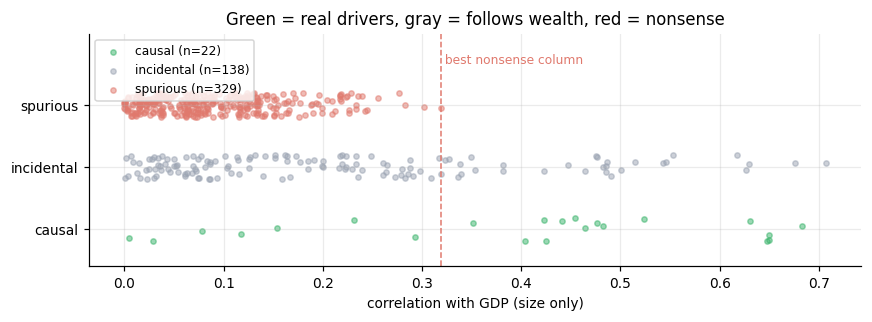

In [14]:
#@title 📊 Chart: every column, coloured by its secret label (double-click to view the code) { display-mode: "form" }
plt.figure(figsize=(8, 3))
jitter = np.random.default_rng(0)

for i, role in enumerate(ROLES):
    rows = ranked[ranked["role"] == role]
    plt.scatter(rows["correlation"], i + jitter.uniform(-0.2, 0.2, len(rows)),
                s=12, alpha=0.5, color=ROLE_COLORS[role],
                label=f"{role} (n={len(rows)})")

plt.axvline(best_nonsense["correlation"], color=RED, linestyle="--", linewidth=1)
plt.text(best_nonsense["correlation"], 2.62, " best nonsense column",
         color=RED, fontsize=8, va="bottom")
plt.yticks(range(len(ROLES)), ROLES)
plt.ylim(-0.6, 3.15)
plt.xlabel("correlation with GDP (size only)")
plt.title("Green = real drivers, gray = follows wealth, red = nonsense")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## Takeaway

- **Consequences of wealth match causes shoulder for shoulder.** The strongest
  column of all merely *follows* wealth, and three of the top eight do. Nothing in
  the ranking marks which is which.
- **The strongest of 333 nonsense columns reaches $|r| \approx 0.32$** — rank 46,
  ahead of 7 of the 22 real drivers. Not for any reason: hundreds of random shots
  at a target will put a few near the bullseye.
- So *"we found a strong correlation"* means nothing until you know **how many
  correlations were tested** to find it.


### ⭐ Bonus. Guess the role

Optional, and worth two minutes. Run the next cell: it hands you **six columns**
with their correlation against GDP and nothing else — no description, no label,
which is the situation you are actually in. Then label each one.

The point is not the score. The point is noticing *which* mistakes you make: the
official-sounding column you wave through, and the honest statistic you throw out
because it sounds trivial.


In [ ]:
# The six columns to label. All you get is the name and the correlation.
print(f"{'column':<38}{'|r| with GDP':>14}\n")
for _c in QUIZ_PICKS:
    print(f"{_c:<38}{abs(np.corrcoef(X[_c], y)[0, 1]):>14.3f}")


In [ ]:
# 🎯 YOUR TURN (bonus) — label the six columns printed above.
#
# 💭 Think first: a column correlating 0.65 with GDP — how much does that narrow
#    down what KIND of column it is? And what does a column at 0.01 tell you:
#    that it is nonsense, or only that it is not correlated?
#
# 🎯 Implement: replace each ... with "causal", "incidental" or "spurious"
#    (in quotes). Leave the column names exactly as they are.
my_guesses = {
    "rule_of_law_index":               ...,   # |r| = 0.65
    "pct_employment_agriculture":      ...,   # |r| = 0.46
    "tourism_receipts_usd":            ...,   # |r| = 0.24
    "observed_inclusion_proxy_18":     ...,   # |r| = 0.24
    "unesco_world_heritage_sites":     ...,   # |r| = 0.14
    "gross_capital_formation_pct_gdp": ...,   # |r| = 0.01
}


In [ ]:
must_fill(my_guesses=my_guesses)

_unknown = [c for c in my_guesses if c not in ROLE]
if _unknown:
    raise ValueError(f"Not columns in this table: {_unknown} — keep the names as they were.")

_right = 0
print(f"{'column':<38}{'you said':>12}{'actually':>13}")
for _c, _guess in my_guesses.items():
    _truth = ROLE[_c]
    _right += _guess == _truth
    print(f"{_c[:36]:<38}{_guess:>12}{_truth:>13}  {'✓' if _guess == _truth else '✗'}")

_commonest = codebook["role"].value_counts().drop("target", errors="ignore")
_blind = len(my_guesses) * _commonest.iloc[0] / _commonest.sum()
print(f"\n{_right} out of {len(my_guesses)}.")
print(f'Answering "{_commonest.index[0]}" six times scores about {_blind:.0f}. '
      "Correlation carries no label.")


Whatever you scored: **you had no signal to score with.** Correlation is one
number and the label is not in it. Three of the six are worth dwelling on:
`tourism_receipts_usd` and `observed_inclusion_proxy_18` sit at the *same*
correlation, $0.24$, and one is a real statistic while the other is nonsense — and
`gross_capital_formation_pct_gdp` is a genuine driver of national wealth that
correlates with it at $0.01$.

That is the whole of Chapter 1 — and the reason the rest of the notebook is about
validation rather than about picking columns.


---

# Chapter 2 · The Crash

### When a perfect training score is the bad news

Ranking columns one at a time cannot weigh them against each other, so we fit all
493 together in a single **regression**, estimating a **coefficient** $w$ for
each:

$$\text{predicted GDP} \;=\; w_1 \times (\text{column 1}) \;+\; w_2 \times (\text{column 2}) \;+\; \dots$$

**We hold data back:** fit on 80% of countries, keep 20% hidden. Scoring on the
countries the model learned from measures memorisation, not learning.

**The score is $R^2$**: $1.0$ is perfect, $0.0$ is no better than guessing the
average, **below $0$ is worse than guessing**. Not a percentage, no floor.

**Keep in mind:** 203 training countries, 493 columns — far more parameters than
observations. Every model from here to the end predicts **GDP per capita in
dollars**, the same target Chapter 1 ranked against, so every $R^2$ in this
notebook is measured on one scale and comparable to every other.


In [ ]:
#@title 📊 Visualization: how to read an R² (double-click to view the code) { display-mode: "form" }
_R2 = [
    ("R² = 1.0", "Every prediction exactly right.", GREEN),
    ("R² = 0.6", "Respectable. Explains most of the variation between countries.", PURPLE),
    ("R² = 0.0", "No better than answering &ldquo;the world average&rdquo; every time.", AMBER),
    ("R² = −11", "Worse than the world average. There is no floor.", RED),
]
display(HTML(panel(
    "".join(card(f'<span style="color:{c}">{t}</span>', b, accent=c) for t, b, c in _R2),
    eyebrow="R² is not a percentage")))


In [ ]:
# Split the countries, and put every column on the same scale.
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=SEED)

scaler = StandardScaler().fit(X_train)     # measured on training data only
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

n_train = len(y_train)
print(f"learning from : {n_train} countries")
print(f"held back     : {len(y_test)} countries")
print(f"columns used  : {X_train_s.shape[1]}")

## Exercise 3 — Fit the regression

| you want to... | use |
|---|---|
| create a plain regression | `LinearRegression()` |
| train it | `model.fit(X_train_s, y_train)` |
| make predictions | `model.predict(X_train_s)` — or `X_test_s` |
| score predictions | `r2_score(y_train, predictions)` |

Whatever data you predict on, score it against the matching answers.


### Your turn


In [ ]:
# 🎯 YOUR TURN — Exercise 3: fit a regression on all 493 columns and score it.
#
# 💭 Think first: with 493 coefficients to estimate and only 203 training
#    countries, what do you expect the TRAINING score to be? And the score on the
#    51 countries the model has never seen?
#
# 🎯 Implement: record both predictions, fit `model`, then score it on the
#    held-back countries in `test_r2`. Step 2 is done for you as the pattern.
# Your two predictions (anything from below 0 up to 1.0):
my_train_guess = ...
my_test_guess = ...

# Step 1 — create the model and train it, in one line.
#          Hint: LinearRegression().fit(X_train_s, y_train)
model = ...

# Step 2 — score it on the countries it learned from. (Given — the pattern.)
train_r2 = r2_score(y_train, model.predict(X_train_s))

# Step 3 — now the same line for the 51 countries it has never seen.
#          Hint: the same as Step 2, with "test" everywhere instead of "train".
test_r2 = ...

must_fill(model=model, train_r2=train_r2, test_r2=test_r2)

compare("Training score", my_train_guess, train_r2, "{:.3f}")
compare("Test score", my_test_guess, test_r2, "{:.3f}")

**A perfect training score**, and a far worse one on countries it never saw.

With 493 coefficients and only 203 observations there are **more free parameters
than data points**, so the model can always pass exactly through every training
country — like fitting a curve wiggly enough to hit all 5 dots, which then
predicts nonsense for a 6th.

The perfect training score is not the achievement. **It is the symptom.**


In [ ]:
#@title 📊 Chart: predicted against actual, four feature counts (double-click to view the code) { display-mode: "form" }
# Same model, four feature counts. Left column: the countries it trained on.
# Right column: the countries it never saw. On the diagonal = right.
_snapshot_ps = [5, 100, n_train, X.shape[1]]
fig, axes = plt.subplots(len(_snapshot_ps), 2, figsize=(7.2, 2.05 * len(_snapshot_ps)),
                         sharex=True, sharey=True)

_lo, _hi = y.min(), y.max()
_pad = 0.05 * (_hi - _lo)
_lim = (_lo - _pad, _hi + _pad)

for _row, _p in enumerate(_snapshot_ps):
    _sc = StandardScaler().fit(X_train[:, :_p])
    _A, _B = _sc.transform(X_train[:, :_p]), _sc.transform(X_test[:, :_p])
    _m = LinearRegression().fit(_A, y_train)
    for _col, (_lab, _xv, _yv, _colour) in enumerate([
            ("train", y_train, _m.predict(_A), TRAIN_COLOR),
            ("test", y_test, _m.predict(_B), TEST_COLOR)]):
        ax = axes[_row, _col]
        ax.plot(_lim, _lim, ls="--", lw=0.8, color="#c9cede")
        ax.scatter(_xv, _yv, s=14, alpha=0.75, color=_colour, edgecolor="none")
        _off = int(np.sum((_yv < _lim[0]) | (_yv > _lim[1])))
        ax.set_title(f"{_lab}   R² = {r2_score(_xv, _yv):>8.3f}"
                     + (f"   ({_off} off-chart)" if _off else ""),
                     fontsize=8, loc="left",
                     color=_colour if _colour != GRAY else "#5b6270")
        ax.set_xlim(_lim)
        ax.set_ylim(_lim)
        if _col == 0:
            ax.set_ylabel(f"p = {_p}\npredicted GDP", fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("actual GDP per capita (USD)", fontsize=8)

fig.suptitle("The left column improves all the way down. The right column falls apart.",
             fontsize=9.5, y=0.997)
plt.tight_layout()
plt.show()


**Read down the left column, then down the right.** On the left, the predictions
tighten onto the diagonal until, at 493 columns, every training country is exactly
right. On the right — the countries the model never saw — the cloud loosens, then
scatters, then leaves the chart entirely.

A model that genuinely learned something hugs the diagonal in **both** columns.
Nothing here does.

**One oddity, worth noticing now.** The bottom row uses *every* column — more than
twice as many columns as countries — and its test panel is visibly tidier than the
row above it. Hold that thought; the bonus section below is about it.


In [ ]:
# Refit using more columns each time.
def fit_with(p, target=None, split_seed=SEED):
    """Fit plain least squares on the first `p` columns.

    Args:
        p: how many columns to use, taken in codebook order.
        target: values to predict (defaults to GDP in dollars).
        split_seed: which 80/20 split to use.

    Returns:
        (train R², test R², total size of the fitted coefficients).
    """
    target = y.values if target is None else target
    A0, B0, a, b = train_test_split(X.values, target, test_size=0.2, random_state=split_seed)
    sc = StandardScaler().fit(A0[:, :p])
    A, B = sc.transform(A0[:, :p]), sc.transform(B0[:, :p])
    m = LinearRegression().fit(A, a)
    return (r2_score(a, m.predict(A)),
            r2_score(b, m.predict(B)),
            np.linalg.norm(m.coef_))


rows = []
for p in [5, 25, 50, 100, 140, 170, 190, 200, 203, 206, 215, 240, 300, 400, 493]:
    train_score, test_score, weight_size = fit_with(p)
    rows.append({"columns": p, "train": train_score,
                 "test": test_score, "weight_size": round(weight_size)})

sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))


In [ ]:
#@title 📊 Chart: scores, and coefficient size, as columns are added (double-click to view the code) { display-mode: "form" }
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(7.6, 5.6), sharex=True)

for ax in (ax_top, ax_bot):
    ax.axvspan(n_train * 0.9, n_train * 1.15, color=RED, alpha=0.10, lw=0)
    ax.axvline(n_train, color=RED, linestyle="--", linewidth=1)

ax_top.plot(sweep["columns"], sweep["train"], marker="o", ms=4,
            color=TRAIN_COLOR, label="training score — the model saw this data")
ax_top.plot(sweep["columns"], sweep["test"], marker="o", ms=4,
            color=TEST_COLOR, label="test score — the model did not")
ax_top.text(n_train * 1.18, 0.45, f"columns = {n_train} countries",
            fontsize=8, color=RED)
ax_top.axhline(0, color="#c9cede", linewidth=0.8)
ax_top.set_yscale("symlog", linthresh=1)
ax_top.set_ylabel("R²")
ax_top.set_title("The test score collapses where columns = countries")
ax_top.legend(fontsize=8, loc="lower left")

ax_bot.plot(sweep["columns"], sweep["weight_size"], marker="o", ms=4, color=PURPLE2)
ax_bot.set_yscale("log")
ax_bot.set_xlabel("number of columns given to the model")
ax_bot.set_ylabel("total coefficient size")
ax_bot.set_title("...exactly where the coefficients explode")

plt.tight_layout()
plt.show()


## Reading the chart

**The collapse is centred where columns = countries (203)** — the point where the
model first has just enough freedom to pass exactly through every training country,
and no freedom left over. The bottom panel says why: the coefficients it needs
there are enormous, and enormous coefficients multiply small differences into huge
errors.

**And then, past that point, the test score climbs back out.** That is not a
glitch. It has a name and a mechanism, and the bonus section below is about it —
because the reason the wheels come back on is the same reason Chapter 3 works.

## Takeaway

- **A perfect training score is not an achievement.** It is what you get whenever
  the model has more free parameters than you have observations.
- **The failure is not gradual.** At 203 columns the model scores $0.996$ on the
  countries it learned from and $-11$ on the ones it did not.
- **Where you land on that curve is luck.** Nothing in the training score warns
  you that you are standing on the cliff.


### ⭐ Bonus. The second descent — why the wheels come back on

*Optional. It answers the question the chart just raised, and it is the bridge into
Chapter 3.*

The classical story has two zones: **too simple**, where the model cannot capture
the pattern, and **too complex**, where it memorises noise. Add columns and you
slide from the first into the second. One hill, one summit, done.

The chart above does not do that. It craters at 203 columns and then *recovers* —
and it recovers while you are feeding it columns that are pure nonsense. This
pattern has a name, **double descent**, and it has three zones rather than two.
The whole of it is visible in one place: **the total size of the coefficients.**

The sweep below is the table you just read, on a much finer grid — same target,
same split, same seed. Only the resolution changes.


In [ ]:
# 🎯 YOUR TURN (bonus) — two predictions before you see the curve.
#
# 💭 Think first: past 203 columns, every column being added is nonsense. Two
#    things could happen — the test score keeps falling forever, or it comes back.
#    Whichever you expect, ask yourself what would have to be true of the
#    COEFFICIENTS for it to happen.
#
# 🎯 Implement: fill in two numbers. Nothing depends on them being right.

# At roughly what number of columns do you expect the test score to be at its worst?
my_worst_p_guess = ...

# And at 493 columns — all of them, mostly nonsense — what test R² do you expect?
my_p493_guess = ...


In [ ]:
# The same sweep as above on a much finer grid — same target (GDP in dollars),
# same 80/20 split, same seed. Only the resolution changes.
dd_ps = sorted(set(list(range(2, 40, 4)) + list(range(40, 180, 10))
                   + list(range(180, 232, 3)) + list(range(232, 300, 10))
                   + list(range(300, 493, 20)) + [X.shape[1]]))

dd = pd.DataFrame([dict(zip(("train", "test", "weight_size"), fit_with(p)), columns=p)
                   for p in dd_ps])[["columns", "train", "test", "weight_size"]]

first = dd[dd["columns"] < n_train * 0.6]
best_early = first.loc[first["test"].idxmax()]
worst = dd.loc[dd["test"].idxmin()]
biggest = dd.loc[dd["weight_size"].idxmax()]
final = dd.iloc[-1]

compare("Columns at the worst test score", my_worst_p_guess, worst["columns"], "{:,.0f}")
compare("Test R² using every column", my_p493_guess, final["test"], "{:.3f}")

print(f"""
  THE THREE ZONES
    zone 1  best score before the cliff   R² = {best_early['test']:+.3f} at {best_early['columns']:.0f} columns
    zone 2  worst score at the cliff      R² = {worst['test']:+.3f} at {worst['columns']:.0f} columns
    zone 3  score using every column      R² = {final['test']:+.3f} at {final['columns']:.0f} columns

  TOTAL COEFFICIENT SIZE
    at {dd.iloc[0]['columns']:.0f} columns {dd.iloc[0]['weight_size']:14,.0f}
    at {biggest['columns']:.0f} columns {biggest['weight_size']:12,.0f}   <- the peak
    at {final['columns']:.0f} columns {final['weight_size']:12,.0f}""")


In [ ]:
#@title 📊 Chart: the two descents, and the coefficients behind them (double-click to view the code) { display-mode: "form" }
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 6.4), sharex=True)

_zones = [(0, worst["columns"] * 0.72, GRAY, "zone 1\nfewer columns\nthan countries"),
          (worst["columns"] * 0.72, worst["columns"] * 1.18, RED, "zone 2\nthe cliff"),
          (worst["columns"] * 1.18, max(dd_ps) * 1.02, AMBER, "zone 3\nfar more columns\nthan countries")]

for ax in (ax_top, ax_bot):
    for x0, x1, colour, _ in _zones:
        ax.axvspan(x0, x1, color=colour, alpha=0.10, lw=0)
    ax.axvline(n_train, color=RED, linestyle="--", linewidth=1)

ax_top.plot(dd["columns"], dd["test"], color=TEST_COLOR, lw=1.8,
            label="test score")
ax_top.plot(dd["columns"], dd["train"], color=TRAIN_COLOR, lw=1.4, ls="--",
            label="training score — pinned at 1.0 from the cliff onward")
ax_top.axhline(0, color="#c9cede", lw=0.8)
ax_top.set_yscale("symlog", linthresh=1)
ax_top.set_ylabel("R²")
ax_top.set_title("Two descents, one curve — from a single 80/20 split")
ax_top.legend(fontsize=8, loc="lower left")

for x0, x1, colour, label in _zones:
    ax_top.text((x0 + x1) / 2, 3.0, label, ha="center", va="bottom",
                fontsize=7.5, color=colour, linespacing=1.4,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax_top.set_ylim(worst["test"] * 1.7, 110)      # keep the trough on the chart

ax_top.annotate(f"best model on the whole chart\n{best_early['columns']:.0f} columns, R² = {best_early['test']:.2f}",
                xy=(best_early["columns"], best_early["test"]),
                xytext=(6, -4.5), fontsize=7.5, color="#5b6270",
                arrowprops=dict(arrowstyle="-", lw=0.8, color="#a8afc0"))
ax_top.annotate(f"all {final['columns']:.0f} columns\nR² = {final['test']:.2f}",
                xy=(final["columns"], final["test"]),
                xytext=(final["columns"] - 130, -4.5), fontsize=7.5, color="#5b6270",
                arrowprops=dict(arrowstyle="-", lw=0.8, color="#a8afc0"))

ax_bot.plot(dd["columns"], dd["weight_size"], color=PURPLE2, lw=1.8)
ax_bot.scatter([biggest["columns"]], [biggest["weight_size"]], s=34, color=PURPLE2, zorder=3)
ax_bot.annotate(f"coefficients peak at {biggest['columns']:.0f} columns —\nthe same place the test score bottoms out",
                xy=(biggest["columns"], biggest["weight_size"]),
                xytext=(biggest["columns"] + 45, biggest["weight_size"] * 0.9),
                fontsize=7.5, color=PURPLE2,
                arrowprops=dict(arrowstyle="-", lw=0.8, color=PURPLE2))
ax_bot.set_yscale("log")
ax_bot.set_ylabel("total coefficient size")
ax_bot.set_xlabel("number of columns given to the model")
ax_bot.set_title("The bottom panel explains the top one")

plt.tight_layout()
plt.show()


## Reading the chart

**Zone 1 — fewer columns than countries.** Familiar territory. Each new column
buys flexibility; the test score improves while a column carries signal and sags
once it mostly carries noise. The best model on this entire chart lives here, at
about 80 columns. The line is jagged rather than smooth, and the sag has already
started by 120 columns — the same decline the coarse table above shows at 140.
That is one split talking, and Chapter 5 is about it.

**Zone 2 — about as many columns as countries.** This is the cliff, and it is the
part worth understanding. With 203 columns and 203 training countries there is
**exactly one** set of coefficients that passes through every training point.
Exactly one, so the model has no say in the matter — it must use that one, whatever
it looks like. And to thread 203 points with 203 knobs, that solution needs
enormous coefficients that very nearly cancel each other out. The bottom panel
shows them: they spike within a few columns of where the test score bottoms out,
both of them essentially at 203. Enormous,
finely balanced coefficients are the definition of a brittle prediction. Hand the
model a country that sits slightly off the training pattern, the cancellation stops
being exact, and the leftover gets multiplied by coefficients about sixty times
larger than the two-column model's.

**Zone 3 — far more columns than countries.** Now there are **infinitely many**
coefficient sets that pass through all 203 training points, and the model gets to
choose. Its choice is not arbitrary: least squares — which is what
`LinearRegression` computes — returns the **smallest** of them, the one with the
least total coefficient size. And the more columns you hand it, the more directions
there are to spread the same fit across, so the smallest available solution keeps
getting smaller. The bottom panel is unambiguous: past the peak, coefficient size
falls the whole way, and with all 493 columns the coefficients are **smaller than
the two-column model's**.

So the recovery is **not** "the nonsense columns turned out to contain signal."
They contain no signal. What they provide is *room* — enough directions that the
fit no longer has to be violent to pass through the data.


In [ ]:
#@title 🧩 Visualization: the three zones side by side (double-click to view the code) { display-mode: "form" }
_ZONES = [
    ("Zone 1 · p &lt; n", GRAY,
     "<b>Many solutions fit badly.</b> The model cannot pass through every point, "
     "so it compromises — and a compromise is stable. Coefficients stay modest. "
     "Adding a column helps while the column carries signal."),
    ("Zone 2 · p &asymp; n", RED,
     "<b>Exactly one solution fits perfectly.</b> The model has no choice and no "
     "slack. Threading every point takes enormous, nearly cancelling coefficients. "
     "Perfect on the training set, catastrophic on anything else."),
    ("Zone 3 · p &gt; n", AMBER,
     "<b>Infinitely many solutions fit perfectly</b> — and least squares quietly "
     "returns the <em>smallest</em> one. More columns mean more directions to "
     "share the fit, so the coefficients shrink and predictions calm down again."),
]
display(HTML(panel(
    "".join(card(f'<span style="color:{c}">{t}</span>', b, accent=c) for t, c, b in _ZONES),
    eyebrow="p = columns · n = training countries")))


In [ ]:
# "Least squares returns the smallest of the infinitely many perfect fits."
# Here is that claim, checked. We take the fitted model on all 493 columns and
# walk away from it in directions that leave every training prediction untouched.
# Every model below fits the training countries EXACTLY as well as the original.
A0, B0, a0, b0 = train_test_split(X.values, y.values, test_size=0.2, random_state=SEED)
_sc = StandardScaler().fit(A0)
A, B = _sc.transform(A0), _sc.transform(B0)
_fit = LinearRegression().fit(A, a0)

# Directions in which the training predictions do not move at all.
_, _s, _vt = np.linalg.svd(A)
_free = _vt[(_s > 1e-8).sum():]
_rng = np.random.default_rng(0)

print(f"all {A.shape[1]} columns, the same split as above:\n")
print(f"{'coefficient size':>18}{'train R²':>11}{'test R²':>11}")
for _step in [0, 1, 2, 4, 8]:
    _tests, _sizes, _trains = [], [], []
    for _ in range(20):
        _detour = _free.T @ _rng.normal(size=_free.shape[0])
        _detour *= _step * np.linalg.norm(_fit.coef_) / np.linalg.norm(_detour)
        _w = _fit.coef_ + _detour
        _sizes.append(np.linalg.norm(_w))
        _trains.append(r2_score(a0, A @ _w + _fit.intercept_))
        _tests.append(r2_score(b0, B @ _w + _fit.intercept_))
    _tag = "  ← what least squares hands you" if _step == 0 else ""
    print(f"{np.mean(_sizes):>18,.0f}{np.mean(_trains):>11.4f}"
          f"{np.median(_tests):>11.3f}{_tag}")


**Every row fits the training data perfectly** — the training column stays pinned
at $1.0000$ down the whole table — and the test score falls off a cliff as the
coefficients grow. Among the infinitely many models that memorise the training set
flawlessly, the small ones generalise and the large ones do not, and the solver
silently handed you the smallest available.

## Takeaway

- **The gentleness in zone 3 is regularisation.** Nobody asked for it and nobody
  tuned it: it is a side effect of least squares preferring the smallest solution.
  **Chapter 3 does the same thing deliberately, with a knob you control** — which
  is why these two chapters belong together. Double descent is the accident;
  regularisation is the policy.
- **The dangerous region is columns ≈ observations**, not "lots of columns". A
  model with ten times more parameters than data points can be *safer* than one
  sitting exactly on the cliff.
- **Never read a training score.** From the cliff rightward it is exactly $1.0$
  everywhere, and it is $1.0$ for the best and the worst model on the chart.
- **Getting there by accident is still worse than getting there on purpose.** The
  best model on this curve uses about 80 columns, not 493 — and the tuned model in
  Chapter 3 beats both.

*Three honest caveats.* The columns enter in codebook order, so the second descent
happens to coincide with feeding the model nonsense; the shape comes from the
*count*, not from what is in them. The recovery depends on least squares choosing
the minimum-size solution — a different fitting rule would land somewhere else on
the plateau, as the table above shows. And the right-hand plateau is visibly bumpy,
because like every other number so far it comes from **one** 80/20 split; Chapter 5
is about why one split wobbles.

*If this feels like an exotic edge case: it is the ordinary operating regime of
every large model you have heard of. They have far more parameters than training
examples, and they sit in zone 3.*


---

# Chapter 3 · The Patch

### One parameter changes everything

The model failed because it was free to choose arbitrarily large coefficients. So
we constrain it: **regularisation** adds a *penalty term*, so large coefficients
carry a cost, and we sweep the strength of that penalty to find what predicts best
on held-back countries.

$$\underbrace{\text{prediction error}}_{\text{fit the data}} \;+\; \underbrace{\alpha \times \text{size of the coefficients}}_{\text{penalty term}}$$

**$\alpha$ (alpha)** sets the penalty strength — a **hyperparameter**, chosen
before fitting rather than estimated from the data, and found by trying values.

| $\alpha$ | effect |
|---|---|
| $0$ | no penalty — Chapter 2's model |
| too small | still overfits |
| **well chosen** | keeps the informative columns, discards the rest |
| too large | predicts close to the average |

Three standard flavours, differing only in how they measure "size":

- **Ridge** penalises the sum of *squared* coefficients. It shrinks every
  coefficient toward zero but none to exactly zero, so all 493 columns stay in.
- **Lasso** penalises the sum of *absolute* coefficients. That change of shape
  drives many coefficients to **exactly zero**, making Lasso a feature selector as
  well as a shrinker.
- **Elastic Net** blends the two, which helps when columns duplicate each other.

We use Lasso below, because the shortlist it produces is what Chapter 4 needs.

*(If the bonus in Chapter 2 stuck: this is the same medicine. Zone 3 kept
coefficients small as an accident of the solver. Here you set the dose.)*

## Exercise 4 — Try a range of penalty strengths

| you want to... | use |
|---|---|
| create a Lasso at a given penalty strength | `Lasso(alpha=a)` |
| train it | `model.fit(X_train_s, y_train)` |
| score it on held-back countries | `r2_score(y_test, model.predict(X_test_s))` |
| count columns it kept | `np.sum(np.abs(model.coef_) > 1e-8)` |
| add to a list | `scores.append(score)` |

*(`> 1e-8` rather than `!= 0`: floating-point arithmetic rarely lands on an exact
zero.)*


### Your turn


In [ ]:
# 🎯 YOUR TURN — Exercise 4: try each penalty strength and record the result.
#
# 💭 Think first: alpha = 0 reproduces Chapter 2's failure, and a very large alpha
#    just predicts the average. How much of the test score do you expect a
#    well-chosen alpha to recover, and how many of the 493 columns will survive?
#
# 🎯 Implement: inside the loop, fit `model` at penalty strength `a` and append
#    its test score to `scores`. The column count is already written for you.
alphas = [1, 10, 50, 100, 200, 500, 1000, 2000, 5000]

scores = []
kept = []

for a in alphas:
    # Fit a Lasso at this penalty strength.
    #    Hint: Lasso(alpha=a).fit(X_train_s, y_train)
    model = ...

    # How well does it do on countries it has never seen?
    #    Hint: r2_score(y_test, model.predict(X_test_s))
    score = ...
    scores.append(score)

    # How many columns did it keep? (Given — bookkeeping, not the idea.)
    kept.append(np.sum(np.abs(model.coef_) > 1e-8))

must_fill(scores=scores, kept=kept)

tuning = pd.DataFrame({"alpha": alphas, "test_score": scores, "columns_kept": kept})
print(f"For reference, Chapter 2's model scored {test_r2:.3f}\n")
print(tuning.to_string(index=False))

In [ ]:
# The best-scoring row.
must_fill(scores=scores, kept=kept)

best_row = tuning.loc[tuning["test_score"].idxmax()]
best_alpha = float(best_row["alpha"])

print(f"best alpha       : {best_alpha:,.0f}")
print(f"its test score   : {best_row['test_score']:.3f}")
print(f"columns it kept  : {int(best_row['columns_kept'])} out of 493")
print(f"\nChapter 2 (no penalty) : {test_r2:.3f}")

In [ ]:
#@title 📊 Chart: test score against the penalty strength, three regularisers (double-click to view the code) { display-mode: "form" }
# All three regularisers on ONE alpha grid — the same values for each, so the
# curves are directly comparable. It is wider and finer than the exercise's grid
# because each flavour's useful range sits in a different place.
sweep_alphas = np.logspace(-2, 4.5, 27)
MAKE = {"Lasso": lambda a: Lasso(alpha=a),
        "Ridge": lambda a: Ridge(alpha=a),
        "Elastic Net": lambda a: ElasticNet(alpha=a, l1_ratio=0.5)}
COLOURS = {"Lasso": PURPLE, "Ridge": PURPLE2, "Elastic Net": AMBER}

curves = {name: [r2_score(y_test, make(a).fit(X_train_s, y_train).predict(X_test_s))
                 for a in sweep_alphas]
          for name, make in MAKE.items()}

# Ridge peaks at a different alpha than Lasso, so keep its own best value.
best_ridge_alpha = float(sweep_alphas[int(np.argmax(curves["Ridge"]))])

plt.figure(figsize=(7.8, 4.4))
for name, curve in curves.items():
    plt.plot(sweep_alphas, curve, marker="o", ms=3, color=COLOURS[name], label=name)

# Where Exercise 4's coarser grid landed, so the exercise and the chart line up.
plt.scatter([best_alpha], [tuning["test_score"].max()], s=90, facecolor="none",
            edgecolor=PURPLE, linewidth=1.6, zorder=4,
            label=f"your Exercise 4 pick (alpha = {best_alpha:,.0f})")

plt.axhline(test_r2, color=RED, linestyle="--", linewidth=1)
plt.text(sweep_alphas[-1] * 1.4, test_r2 + 0.04, "Chapter 2\n(no penalty)",
         color=RED, fontsize=8, ha="right", va="bottom")
plt.axhline(0, color="#c9cede", linewidth=0.8)
plt.xscale("log")
# symlog on y, and limits taken from the data, so no curve is clipped while the
# 0-to-0.6 band everything interesting happens in stays readable.
plt.yscale("symlog", linthresh=1)
_lowest = min(min(c) for c in curves.values())
plt.ylim(_lowest * 1.4, 1.0)
plt.xlim(sweep_alphas[0] * 0.6, sweep_alphas[-1] * 1.6)
# Tick the band the peaks live in; symlog leaves it bare otherwise.
plt.yticks([-3, -2, -1, -0.5, 0, 0.2, 0.4, 0.6, 0.8],
           ["-3", "-2", "-1", "-0.5", "0", "0.2", "0.4", "0.6", "0.8"])
plt.xlabel("alpha — regularisation strength")
plt.ylabel("test score (R²)")
plt.title("Too little penalty overfits; too much under-fits")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print(f"{'on this shared grid':<22}{'best alpha':>12}{'its test R²':>14}")
for name, curve in curves.items():
    _i = int(np.argmax(curve))
    print(f"{name:<22}{sweep_alphas[_i]:>12,.4g}{curve[_i]:>14.3f}")
print(f"\nExercise 4's coarser grid picked alpha = {best_alpha:,.0f} "
      f"({tuning['test_score'].max():.3f}) for Lasso — the same region; a finer\n"
      "grid finds a slightly better value nearby. Chapters 4 and 5 keep using "
      "alpha = 200.")


## Takeaway

- **One hyperparameter did the work.** A well-chosen penalty lifted the model from
  $0.333$ on unseen countries to $0.577$, discarding 364 of the 493 columns on the
  way.
- **All three flavours get to roughly the same place**, each at its own $\alpha$.
  The knob matters far more than which flavour you pick.
- **Both extremes fail**, and the value in between is found by trying, not by
  deriving.

Lasso also produced a **shortlist** of 129 columns — apparently the answer to the
second half of the brief. Chapter 4 checks it.

> ⚠️ **One thing we just did that you should not do.** We chose $\alpha$ by looking
> at the held-back countries, then reported the score on those same countries. That
> makes $0.577$ slightly optimistic — the held-back set has quietly become part of
> the training procedure. The clean version needs a third split, or the
> cross-validation in Chapter 5. Keep it in mind; it is the single most common way
> a real model's reported score turns out to be too good.


---

# Chapter 4 · The Reveal

### The model kept the wrong columns

Lasso's shortlist looks like an answer to *what drives national wealth?* So we
measure where each model's importance actually falls, then put the same question to
a different class of model.

Models report **feature importance** — a score per column for how much it
contributes to predictions. For Lasso that is the absolute coefficient; a forest
computes it differently. Total those scores and ask:

> **Of a model's total feature importance, what share falls on the 22 genuinely
> causal columns?**

22 of 493 columns are real drivers, or **4.5%** — a model indifferent to the
economics would land near that. We ask **Lasso** and a **Random Forest** (many
decision trees, averaged).

## Exercise 5 — Measure the importance shares

| you want to... | use |
|---|---|
| fit a forest | `RandomForestRegressor(n_estimators=300, random_state=SEED)` |
| the forest's importance scores | `forest.feature_importances_` |
| Lasso's importance scores | `np.abs(lasso.coef_)` |
| importance on causal columns only | `importance[roles == "causal"].sum()` |
| total importance | `importance.sum()` |

`roles` holds one label per column.


### Your turn


In [ ]:
# 🎯 YOUR TURN — Exercise 5: measure where each model's importance lands.
#
# 💭 Think first: only 22 of the 493 columns are genuinely causal — 4.5%. Will
#    Lasso and the forest concentrate on those, or spread out? And will the two
#    methods agree with each other?
#
# 🎯 Implement: record both predictions, then fill in Lasso's importance scores
#    and its causal share. The same two lines for the forest are given.
roles = np.array([ROLE.get(c, "incidental") for c in FEATURES])

lasso = Lasso(alpha=best_alpha).fit(X_train_s, y_train)
forest = RandomForestRegressor(n_estimators=300, random_state=SEED).fit(X_train_s, y_train)

print(f"Lasso  test score : {r2_score(y_test, lasso.predict(X_test_s)):.3f}")
print(f"Forest test score : {r2_score(y_test, forest.predict(X_test_s)):.3f}")

# Your predictions, as percentages (e.g. 30 means 30%):
my_lasso_guess = ...
my_forest_guess = ...

# Lasso's importance scores, and the share falling on causal columns.
#    Hint: np.abs(lasso.coef_)
lasso_importance = ...
#    Hint: lasso_importance[roles == "causal"].sum() / lasso_importance.sum()
lasso_causal_share = ...

# The same two lines for the forest — given, so you write the pattern only once.
# (A forest exposes feature_importances_, already positive, so no np.abs.)
forest_importance = forest.feature_importances_
forest_causal_share = forest_importance[roles == "causal"].sum() / forest_importance.sum()

must_fill(lasso_importance=lasso_importance, forest_importance=forest_importance,
          lasso_causal_share=lasso_causal_share,
          forest_causal_share=forest_causal_share)

compare("Lasso  — importance on the 22 causal columns",
        my_lasso_guess, lasso_causal_share * 100, "{:.1f}%")
compare("Forest — importance on the 22 causal columns",
        my_forest_guess, forest_causal_share * 100, "{:.1f}%")

In [ ]:
must_fill(lasso_importance=lasso_importance, forest_importance=forest_importance)

print(f"{'kind of column':<16}{'how many':>10}{'Lasso':>10}{'Forest':>10}")
for role in ROLES:
    lasso_share = lasso_importance[roles == role].sum() / lasso_importance.sum()
    forest_share = forest_importance[roles == role].sum() / forest_importance.sum()
    print(f"{role:<16}{int((roles == role).sum()):>10}{lasso_share:>9.1%}{forest_share:>10.1%}")

In [ ]:
#@title 📊 Chart: how each model distributes feature importance (double-click to view the code) { display-mode: "form" }
from matplotlib.patches import Patch

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.5, 4.2))

lasso_shares = [lasso_importance[roles == r].sum() / lasso_importance.sum() for r in ROLES]
forest_shares = [forest_importance[roles == r].sum() / forest_importance.sum() for r in ROLES]

width = 0.35
pos = np.arange(len(ROLES))
ax_left.bar(pos - width / 2, lasso_shares, width, hatch="///",
            color=[ROLE_COLORS[r] for r in ROLES], alpha=0.55, edgecolor="white")
ax_left.bar(pos + width / 2, forest_shares, width,
            color=[ROLE_COLORS[r] for r in ROLES])
_indifferent = (roles == "causal").sum() / len(FEATURES)
ax_left.axhline(_indifferent, color="black", linestyle=":", linewidth=1)
ax_left.text(len(ROLES) - 0.5, _indifferent + 0.015,
             f"{_indifferent:.1%} = no preference at all", fontsize=7.5, ha="right")
ax_left.set_xticks(pos)
ax_left.set_xticklabels([f"{r}\n({int((roles == r).sum())} cols)" for r in ROLES])
ax_left.set_ylabel("share of total feature importance")
ax_left.set_title("Where each model's importance lands")
ax_left.legend(handles=[Patch(facecolor="#cfd4e0", hatch="///", label="Lasso"),
                        Patch(facecolor="#8a93a8", label="Random Forest")], fontsize=8)

order = np.argsort(forest_importance)[::-1][:15]
ax_right.barh(range(15), forest_importance[order][::-1],
              color=[ROLE_COLORS[roles[i]] for i in order][::-1])
ax_right.set_yticks(range(15))
ax_right.set_yticklabels([FEATURES[i][:28] for i in order][::-1], fontsize=7)
ax_right.set_xlabel("feature importance")
ax_right.set_title("The forest's top 15 columns")

plt.tight_layout()
plt.show()


## Two models, two stories

**Two methods, the same data, test scores within a few points of each other — and
completely different answers to "what drives national wealth."**

The forest concentrates on the 22 real drivers; Lasso spreads its importance
across columns that merely follow wealth, plus a substantial share on nonsense.

**You could not have chosen between them using the test score.**


In [ ]:
# Where do the openly implausible columns rank by importance? (1 = highest)
silly = ["scrabble_score_country_name", "name_numerology_score", "name_lucky_number",
         "vowels_in_country_name", "unesco_world_heritage_sites",
         "passport_visa_free_destinations"]

lasso_place = (-lasso_importance).argsort().argsort()
forest_place = (-forest_importance).argsort().argsort()

print(f"{'column':<40}{'Lasso':>8}{'Forest':>8}")
for c in silly:
    i = FEATURES.index(c)
    note = "" if lasso_importance[i] > 1e-8 else "   thrown out by Lasso"
    print(f"{c:<40}{lasso_place[i] + 1:>8}{forest_place[i] + 1:>8}{note}")

# And the nonsense it promoted instead: the columns Lasso ranked highest that the
# codebook labels spurious, with how weakly each one correlates with GDP on its own.
print(f"\n{'nonsense Lasso ranked highest':<40}{'Lasso':>8}{'Forest':>8}{'|r|':>8}")
_top_spurious = [i for i in (-lasso_importance).argsort() if roles[i] == "spurious"][:3]
for i in _top_spurious:
    print(f"{FEATURES[i]:<40}{lasso_place[i] + 1:>8}{forest_place[i] + 1:>8}"
          f"{abs(np.corrcoef(X[FEATURES[i]], y)[0, 1]):>8.3f}")

## The part that should worry you

Lasso threw out every one of those — numerology and Scrabble scores correlate too
weakly to survive. Its nonsense importance went to **plausible-sounding** columns
instead. Its 11th and 12th most important columns out of all 493 are
`regional_productivity_estimator_247` and `derived_resilience_estimator_128`: pure
noise, correlated with GDP at only $0.14$ and $0.16$ on their own, and named like
something a ministry would publish. Neither the correlation ranking in Chapter 1
nor the column name would have flagged either one.

> You were never going to ship a model built on Scrabble scores. You might easily
> ship one built on an official-sounding column nobody checked.

## Takeaway

- **Predicting well and explaining correctly are different achievements.** Lasso
  and the forest score $0.577$ and $0.611$ while putting $9.1\%$ and $51.9\%$ of
  their importance on the 22 real drivers.
- **The test score cannot arbitrate** between the two explanations.
- **The dangerous nonsense is the plausible kind.** Lasso discarded every openly
  silly column, then spent $34.3\%$ of its importance on respectable-looking ones.

Before publishing an explanation, fit a different class of model and check whether
it survives.


---

# Chapter 5 · The Trust

### One split is not an answer

Every number to this point came from the same **random** 80/20 split. A different
draw puts different countries in the held-back group, and gives a different score —
so we re-run the same models over several splits and report the spread.

> The restaurant problem: one excellent meal does not tell you whether the
> restaurant is excellent or you came on a good night.


In [ ]:
# The same model, three different random splits.
for attempt in [0, 1, 2]:
    A, B, a, b = train_test_split(X.values, y.values, test_size=0.2, random_state=attempt)
    sc = StandardScaler().fit(A)
    m = Lasso(alpha=best_alpha).fit(sc.transform(A), a)
    print(f"split {attempt} : test score = {r2_score(b, m.predict(sc.transform(B))):.3f}")

In [ ]:
#@title 📊 Chart: the same three models over 60 different random splits (double-click to view the code) { display-mode: "form" }
resample_models = {
    "OLS (no penalty)": (LinearRegression(), RED),
    f"Ridge (alpha={best_ridge_alpha:,.0f})": (Ridge(alpha=best_ridge_alpha), PURPLE2),
    f"Lasso (alpha={best_alpha:,.0f})": (Lasso(alpha=best_alpha), PURPLE),
}

resamples = {}
for _name, (_model, _colour) in resample_models.items():
    _out = []
    for _seed in range(60):
        A0, B0, a0, b0 = train_test_split(X.values, y.values, test_size=0.2,
                                          random_state=_seed)
        _sc = StandardScaler().fit(A0)
        _m = _model.fit(_sc.transform(A0), a0)
        _out.append(r2_score(b0, _m.predict(_sc.transform(B0))))
    resamples[_name] = np.array(_out)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 3.6),
                                 gridspec_kw={"width_ratios": [1.15, 1]})

for _i, (_name, (_model, _colour)) in enumerate(resample_models.items()):
    _s = resamples[_name]
    ax_l.scatter(_s, np.full(len(_s), _i) + np.random.default_rng(0).uniform(-.13, .13, len(_s)),
                 s=18, alpha=0.6, color=_colour, edgecolor="none")
    ax_l.scatter([np.median(_s)], [_i], marker="|", s=380, color="black", zorder=3)
ax_l.set_xscale("symlog", linthresh=1)
ax_l.axvline(0, color="#c9cede", lw=0.8, ls=":")
ax_l.set_yticks(range(len(resample_models)))
ax_l.set_yticklabels(list(resample_models), fontsize=8)
ax_l.set_xlabel("test score on each of 60 random splits   (bar = median)")
ax_l.set_title("Change only the random seed", fontsize=9.5)

_lasso_name = [k for k in resamples if k.startswith("Lasso")][0]
_s = resamples[_lasso_name]
ax_r.hist(_s, bins=18, color=PURPLE, alpha=0.75)
ax_r.axvline(np.median(_s), color="black", lw=1.2)
ax_r.axvline(_s[SEED], color=AMBER, lw=1.2, ls="--")     # the split used all along
ax_r.set_xlabel("Lasso test score")
ax_r.set_ylabel("how many splits")
ax_r.set_title("Lasso alone (amber = the split we used all along)", fontsize=9.5)

plt.tight_layout()
plt.show()

print(f"{'model':<26}{'median':>9}{'worst':>9}{'best':>9}{'spread':>9}")
for _name, _s in resamples.items():
    print(f"{_name:<26}{np.median(_s):>9.2f}{_s.min():>9.2f}{_s.max():>9.2f}{_s.std():>9.2f}")


## Reading the chart

**Left panel.** Sixty runs of the same three models on the same data. The only
thing that changed between dots is which countries landed in the held-back 20%.
The unregularised model is not one number with a bit of noise around it — it is a
lottery. The regularised models are tighter, which is worth as much as their
higher average.

**Right panel.** The Lasso alone. Our seed-42 split (amber) sits at one particular
place in that histogram. Had you drawn a different seed, you would have written a
different number in the report — and nothing in your output would have told you.

**This is the practical rule.** A single held-out score is one draw from a
distribution you have not looked at. Report the middle *and* the width, or you are
reporting your luck.


Three different answers, same model, same data — only the split changed. Run this
once and report whatever came out, and **nobody could catch you.**

## Cross-validation

**Cross-validation** cuts the countries into 5 groups and fits 5 times, holding
out a different group each time. Every country is predicted exactly once by a
model that never saw it. You report **the average and the spread**.

## Exercise 6 — Cross-validate each model

**What you need:**

| you want to... | use |
|---|---|
| combine scaler + model | `make_pipeline(StandardScaler(), the_model)` |
| run 5-group cross-validation | `cross_val_score(pipeline, X.values, y.values, cv=folds)` |
| average / spread | `scores.mean()` / `scores.std()` |

`folds` is prepared below — it shuffles before splitting, because this file is in
alphabetical order and unshuffled blocks would each be a lopsided slice of the
world.


### Your turn


In [ ]:
# 🎯 YOUR TURN — Exercise 6: cross-validate each model.
#
# 💭 Think first: you have just seen three splits give three different answers.
#    Which of these four models do you expect to vary least across the five
#    groups — and is the best average necessarily the one to trust?
#
# 🎯 Implement: inside the loop, store the five fold scores in `fold_scores`.
#    The pipeline that feeds it is given.
folds = KFold(n_splits=5, shuffle=True, random_state=SEED)

models_to_check = {
    "OLS (all 493)": LinearRegression(),
    "Ridge":         Ridge(alpha=best_ridge_alpha),
    "Lasso":         Lasso(alpha=best_alpha),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=SEED),
}

results = {}
for name, model in models_to_check.items():
    # Scaler + model together, so scaling is redone inside each group. (Given.)
    pipeline = make_pipeline(StandardScaler(), model)

    # Five groups, five scores.
    #    Hint: cross_val_score(pipeline, X.values, y.values, cv=folds)
    fold_scores = ...

    must_fill(pipeline=pipeline, fold_scores=fold_scores)
    results[name] = fold_scores
    print(f"{name:<16} average {fold_scores.mean():+.3f}   spread ±{fold_scores.std():.3f}")

In [ ]:
#@title 📊 Chart: every group, for every model (double-click to view the code) { display-mode: "form" }
must_fill(**{name: list(v) for name, v in results.items()})

plt.figure(figsize=(7.6, 3.4))

names = list(results)
colours = [RED, PURPLE2, PURPLE, GREEN]
for i, name in enumerate(names):
    scores = results[name]
    plt.scatter(scores, [i] * len(scores), s=42, alpha=0.75,
                color=colours[i % len(colours)], edgecolor="none")
    plt.scatter([scores.mean()], [i], marker="|", s=320, color="black", zorder=3)

plt.axvline(0, color="#c9cede", linewidth=0.8, linestyle=":")
plt.yticks(range(len(names)), names)
plt.xscale("symlog", linthresh=1)
plt.xlabel("score on each of the 5 groups   (black bar = average)")
plt.title("Look at the spread, not just the average")
plt.tight_layout()
plt.show()


## Takeaway

- **A score is a draw, not a fact.** The same model on the same data spans a wide
  range depending only on which countries were held back.
- **Cross-validation gives you the spread for free.** Every country is predicted
  once, by a model that never saw it, and you get five numbers instead of one.
- **Read the spread before the average.** A model with a slightly lower mean and a
  much tighter spread is usually the one to ship — you know what you are getting.
- **The unregularised model is not merely worse, it is unpredictable.** That is a
  different and more dangerous kind of bad.

> **And the warning at the end of Chapter 3 just came due.** Lasso reported $0.577$
> on the seed-42 split. Cross-validated, it averages far below that, with a huge
> spread — because $\alpha = 200$ was tuned on *that one split* and does not
> transfer. Ridge, whose penalty was tuned the same way but shrinks more gently,
> holds up. **The honest number for a tuned model is the cross-validated one**, and
> it is the number to ask for.


---

# Summary

You were asked to predict GDP per capita and say what drives it. Here is what the
five chapters established, in the order you will need them.

1. **A strong correlation means nothing until you know how many were tested.** The
   best of 333 nonsense columns reached $|r| = 0.32$ and outranked 7 of the 22
   genuine drivers — by chance, because hundreds of shots at a target will put a
   few near the bullseye. Always ask how many candidates were searched.
2. **A perfect training score is a symptom, not an achievement.** Give a model more
   free parameters than you have observations and it will fit your data exactly,
   every time, regardless of whether there is anything to learn.
3. **The dangerous region is parameters ≈ observations.** That is where the
   coefficients explode and predictions become brittle. Far *more* parameters can be
   safer than exactly enough — which is the double-descent bonus in Chapter 2, and
   the reason "we used a huge model" is not by itself a red flag.
4. **One hyperparameter, chosen empirically, did more than any modelling
   cleverness** — $0.333 \to 0.577$ on unseen countries. Ask what was tuned and how
   the tuning was validated.
5. **Predicting well and explaining correctly are different achievements.** Lasso
   and the Random Forest scored within a few points of each other while putting
   $9\%$ and $52\%$ of their importance on the real drivers. A good test score does
   not license the accompanying story, and no score can arbitrate between two
   stories.
6. **The plausible nonsense is the dangerous nonsense.** Every openly silly column
   was thrown out; the model's wasted importance went to respectable-sounding
   columns nobody checked.
7. **Report a spread, not a number.** Every figure in Chapters 2 to 4 came from one
   random split. Resampled, they turn into wide distributions — and the width is
   part of the finding.

**The four questions to ask of any model brought to you**, in order of how often
they find something:

1. What was the score on data the model had never seen — and how many times was
   that data looked at while tuning?
2. How many candidate features or models were searched to arrive at this one?
3. How much does the score move if the split changes?
4. Does a different class of model tell the same story about *why*?
